In [1]:
# ==============================================================
import numpy as np
import warnings

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.feature import ShapelyFeature
import cartopy.io.shapereader as shpreader


import sys
sys.path.append("/home/nchoi21/utils/python/nbchoi")
import f_nchoi as nb

import colormaps as cmaps
import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from scipy import signal

import os 
import glob
import subprocess
import regionmask

import pandas as pd
import xarray as xr
warnings.filterwarnings("ignore", category=UserWarning)
# ==============================================================

In [2]:
## OPEN Precip
mod = xr.open_dataset('/scratch/nchoi21/CMIP/HighResMIP/climate/Regrid_25yrs_ann_clim_tv.nc').tv[:,0:5,:,:,:].mean('time')
#print(mod)
lsm = regionmask.defined_regions.natural_earth_v5_0_0.land_110  # 110m resolution
mask = lsm.mask(mod.coords['longitude'], mod.coords['latitude'])
ocean_mask = xr.where(mask.isnull(), 1, 0)
mod = mod.where(ocean_mask == 1)


pr = mod[1:]-mod[0]
#print(pr)

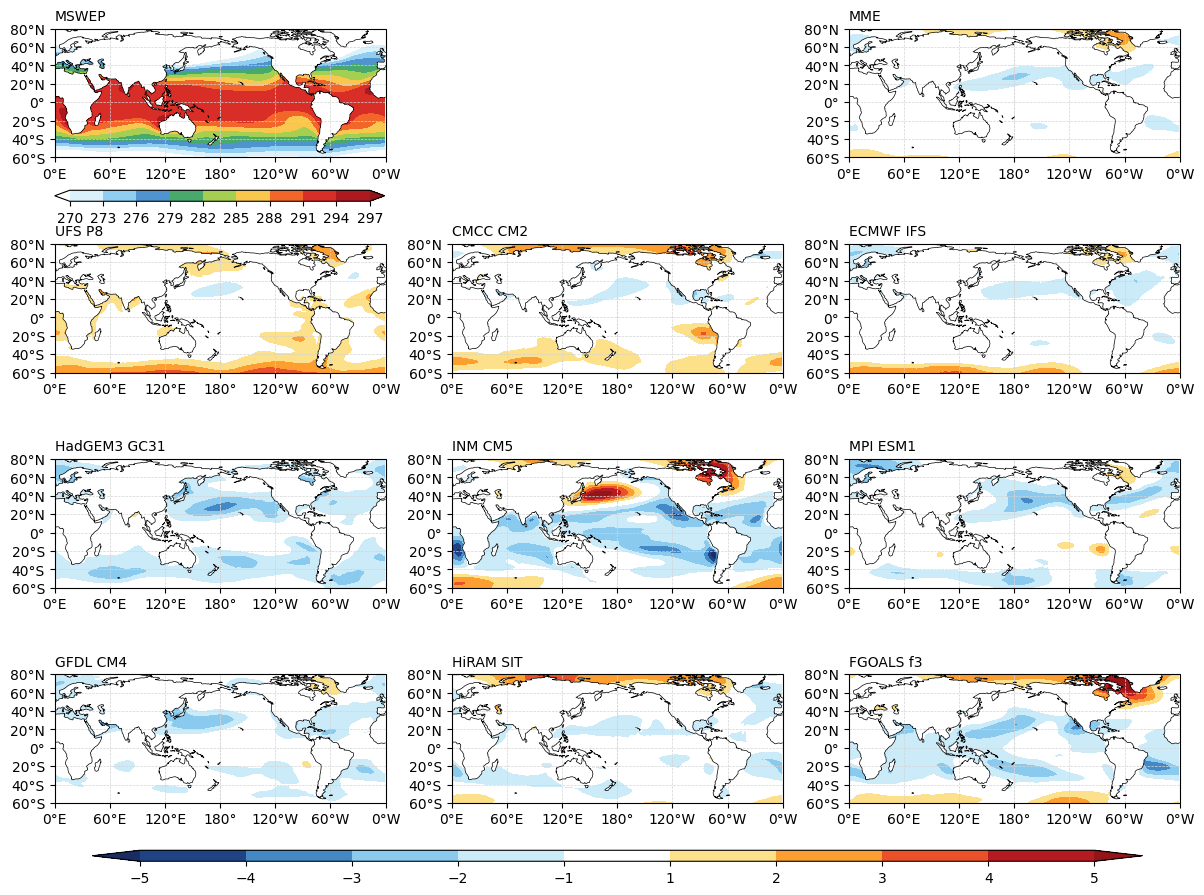

In [3]:
mod = mod.sel(level=850)

fig = plt.figure(figsize=(15,11))
plt.subplots_adjust(bottom=0.2,top=0.95,left=0.05,right=0.8)
model = ['ERA5','UFS P8','CMCC CM2','ECMWF IFS','HadGEM3 GC31','INM CM5','MPI ESM1','GFDL CM4','HiRAM SIT','FGOALS f3']
projection = ccrs.PlateCarree(central_longitude=180.0)
lon_tick = np.arange(-180,181,60) ## Add 1 in end-point
lat_tick = np.arange(-60,81,20)
lon_formatter = LongitudeFormatter(zero_direction_label = True)
lat_formatter = LatitudeFormatter()
plt.set_cmap(cmaps.WhiteBlueGreenYellowRed)   # color map
#clevs = [-3,-2.5,-2,-1.5,-1.0,-0.5,0.5,1.0,1.5,2.0,2.5,3]

clevs = np.arange(270,300,3)
plt.subplot(431,projection=projection)
longitude = mod['longitude']
latitude = mod['latitude']
longitude = longitude - 180
a=plt.contourf(longitude,latitude,mod[0,:,:],levels=clevs,extend='both')
plt.gca().set_yticks(lat_tick,crs=projection)
plt.gca().set_xticks(lon_tick,crs=projection)
plt.gca().xaxis.set_major_formatter(lon_formatter)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_extent([-180, 180, -60, 80], crs=projection)
plt.gca().gridlines(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
#plt.gca().add_feature(cfeature.LAND,linewidth=0.5,edgecolor='black',facecolor='white',zorder=2)
plt.gca().coastlines(linewidth=0.5, edgecolor='black',zorder=3)  # Draw Coastline
#plt.gca().add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black',zorder=3)
plt.gca().set_title('MSWEP',loc='left',fontsize=10)
cax = plt.axes([0.05,0.77,0.22,0.01]) # Left, Bottom, width, height
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')

clevs = np.arange(-5,6,1)
clevs = clevs[clevs!=0]

plt.subplot(4,3,3,projection=projection)
a=plt.contourf(longitude,latitude,mod[1:,:,:].mean('model') - mod[0,:,:],levels=clevs,extend='both')
plt.gca().set_yticks(lat_tick,crs=projection)
plt.gca().set_xticks(lon_tick,crs=projection)
plt.gca().xaxis.set_major_formatter(lon_formatter)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_extent([-180, 180, -60, 80], crs=projection)
plt.gca().gridlines(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
plt.gca().coastlines(linewidth=0.5, edgecolor='black',zorder=3)  # Draw Coastline
plt.gca().set_title('MME',loc='left',fontsize=10)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)

for n in range(0,9):
    plt.subplot(4,3,4+n,projection=projection)
    a=plt.contourf(longitude,latitude,mod[n+1,:,:] - mod[0,:,:],levels=clevs,extend='both')
    plt.gca().set_yticks(lat_tick,crs=projection)
    plt.gca().set_xticks(lon_tick,crs=projection)
    plt.gca().xaxis.set_major_formatter(lon_formatter)
    plt.gca().yaxis.set_major_formatter(lat_formatter)
    plt.gca().set_extent([-180, 180, -60, 80], crs=projection)
    plt.gca().gridlines(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
    plt.gca().coastlines(linewidth=0.5, edgecolor='black',zorder=3)  # Draw Coastline
    plt.gca().set_title(model[n+1],loc='left',fontsize=10)
    plt.set_cmap(cmaps.BlueWhiteOrangeRed)   # color map
    
cax = plt.axes([0.075,0.17,0.7,0.01]) # Left, Bottom, width, height
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')

In [4]:
## OPEN Precip
mod = xr.open_dataset('/scratch/nchoi21/CMIP/HighResMIP/climate/Regrid_25yrs_ann_clim_tv.nc').tv[:,0:5,:,:,:].mean('time')
lsm = regionmask.defined_regions.natural_earth_v5_0_0.land_110  # 110m resolution
mask = lsm.mask(mod.coords['longitude'], mod.coords['latitude'])
ocean_mask = xr.where(mask.isnull(), 1, 0)
mod = mod.where(ocean_mask == 1)

mod_anom = mod - mod.sel(latitude=slice(-20,20)).mean('latitude')

pr = mod_anom[1:]-mod_anom[0]
pr = pr.sel(longitude=slice('210','271'))#.mean('longitude')
print(pr)
pr = pr.mean('longitude')


<xarray.DataArray 'tv' (model: 9, level: 6, latitude: 181, longitude: 61)> Size: 5MB
array([[[[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         ...,
         [ 9.13185692e-01,  9.26469278e-01,  9.33673740e-01, ...,
           1.77963609e-02, -3.03986857e-02, -5.00598435e-02],
         [ 8.61069694e-01,  8.75166080e-01,  8.84092920e-01, ...,
           1.03320344e-01,  6.12388768e-02,  4.69852624e-02],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]],

        [[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
   

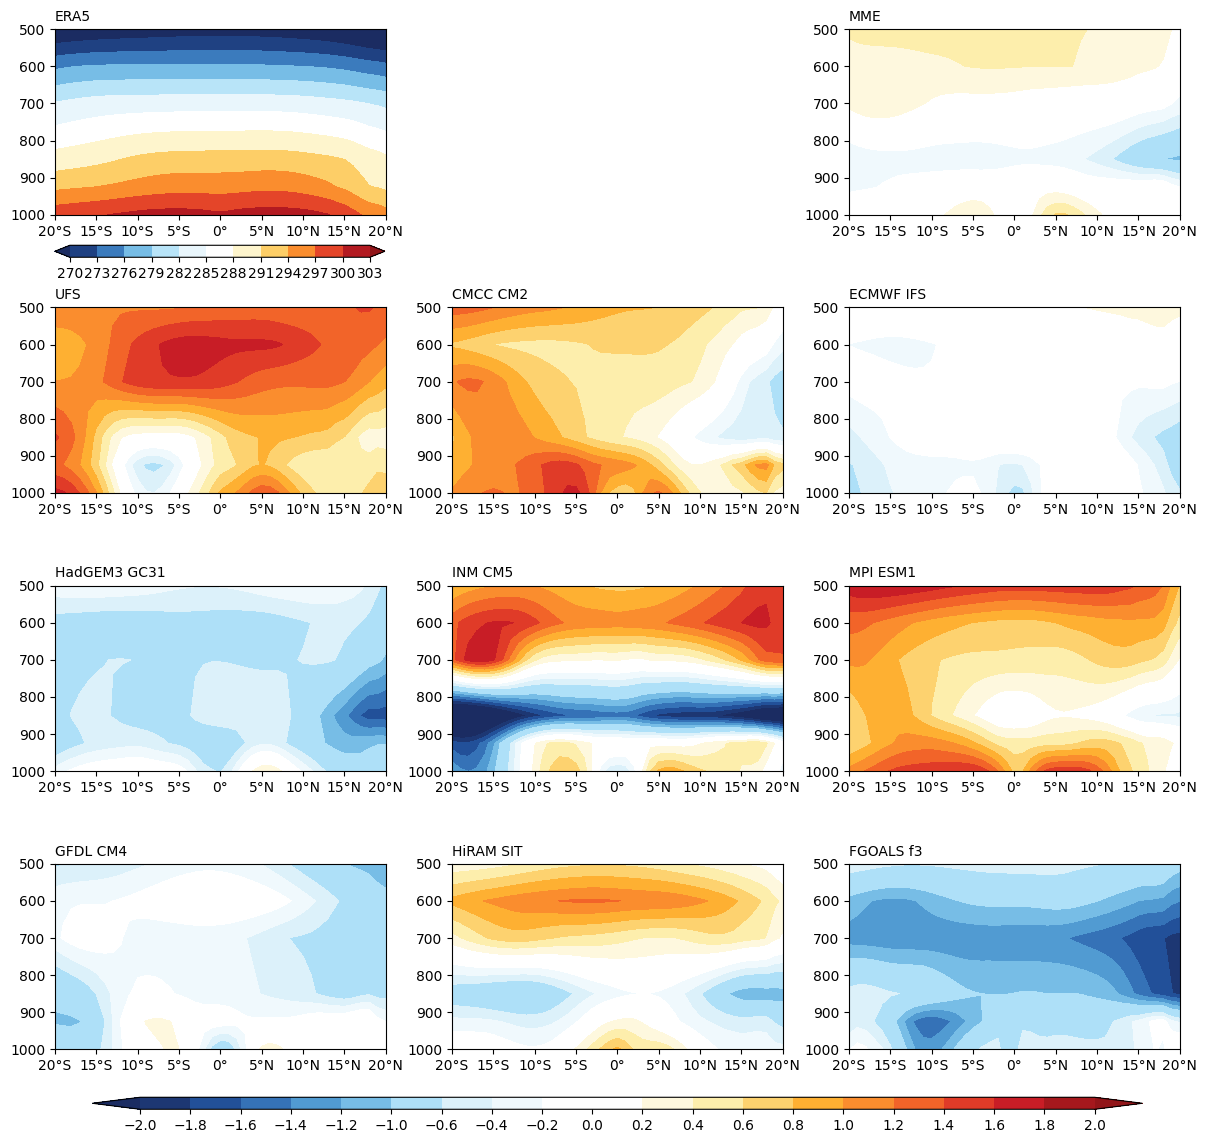

In [5]:
## Moisture Bias (Raw)
mod = mod.sel(longitude=slice('210','271'))
#print(mod)
fig = plt.figure(figsize=(15,12))
plt.subplots_adjust(bottom=0.1,top=0.95,left=0.05,right=0.8)
model = ['ERA5','UFS','CMCC CM2','ECMWF IFS','HadGEM3 GC31','INM CM5','MPI ESM1','GFDL CM4','HiRAM SIT','FGOALS f3']
projection = ccrs.PlateCarree(central_longitude=180.0)
lon_tick = np.arange(-180,181,60) ## Add 1 in end-point
lat_tick = np.arange(-60,81,5)
lon_formatter = LongitudeFormatter(zero_direction_label = True)
lat_formatter = LatitudeFormatter()
#plt.set_cmap(cmaps.WhiteBlueGreenYellowRed)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)# color map
#clevs = [-3,-2.5,-2,-1.5,-1.0,-0.5,0.5,1.0,1.5,2.0,2.5,3]

clevs = np.arange(270,305,3)
#clevs = np.arange(-1,15,1)
#clevs = clevs[clevs!=clevs[6]]
plt.subplot(431)
lev = mod['level']
latitude = mod['latitude']
a=plt.contourf(latitude,lev,mod[0,:,:].mean('longitude'),levels=clevs,extend='both')
plt.gca().set_xticks(lat_tick)
plt.gca().xaxis.set_major_formatter(lat_formatter)
plt.gca().set_title('ERA5',loc='left',fontsize=10)
plt.gca().invert_yaxis()
plt.xlim(-20, 20)
plt.ylim(1000,500)
cax = plt.axes([0.05,0.76,0.22,0.01]) # Left, Bottom, width, height
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')

clevs = np.arange(-2,2.1,0.2)
clevs = clevs[clevs!=clevs[6]]

plt.subplot(4,3,3)
a=plt.contourf(latitude,lev,mod[1:,:,:].mean(('model','longitude')) - mod[0,:,:].mean('longitude'),levels=clevs,extend='both')
#a=plt.contourf(latitude,lev,mod[1:,:,:].mean(('model','longitude')),levels=clevs,extend='both')
plt.gca().set_xticks(lat_tick)
plt.gca().xaxis.set_major_formatter(lat_formatter)
plt.gca().set_title('ERA5',loc='left',fontsize=10)
plt.gca().invert_yaxis()
plt.gca().set_title('MME',loc='left',fontsize=10)
plt.xlim(-20, 20)
plt.ylim(1000,500)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)

for n in range(0,9):
    plt.subplot(4,3,4+n)
    a=plt.contourf(latitude,lev,mod[n+1,:,:].mean('longitude') - mod[0,:,:].mean('longitude'),levels=clevs,extend='both')
    #a=plt.contourf(latitude,lev,mod[n+1,:,:].mean('longitude'),levels=clevs,extend='both')
    plt.gca().set_xticks(lat_tick)
    plt.gca().xaxis.set_major_formatter(lat_formatter)
    plt.gca().set_title('MSWEP',loc='left',fontsize=10)
    plt.gca().invert_yaxis()
    plt.gca().set_title(model[n+1],loc='left',fontsize=10)
    plt.xlim(-20, 20)
    plt.ylim(1000,500)
    plt.set_cmap(cmaps.BlueWhiteOrangeRed)   # color map
    
cax = plt.axes([0.075,0.05,0.7,0.01]) # Left, Bottom, width, height
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')
plt.subplots_adjust(hspace=0.5)

<xarray.DataArray 'tv' (model: 10, level: 6, latitude: 181, longitude: 61)> Size: 5MB
array([[[[         nan,          nan,          nan, ...,          nan,
                   nan,          nan],
         [         nan,          nan,          nan, ...,          nan,
                   nan,          nan],
         [         nan,          nan,          nan, ...,          nan,
                   nan,          nan],
         ...,
         [-49.0851634 , -49.05492524, -49.01962362, ..., -47.97904845,
          -47.89105695, -47.8343224 ],
         [-48.94719648, -48.91531342, -48.8792275 , ..., -47.77520323,
          -47.68917402, -47.6336327 ],
         [-48.70124311, -48.66773347, -48.62992636, ..., -47.62646971,
          -47.54409956, -47.49203419]],

        [[         nan,          nan,          nan, ...,          nan,
                   nan,          nan],
         [         nan,          nan,          nan, ...,          nan,
                   nan,          nan],
         [        

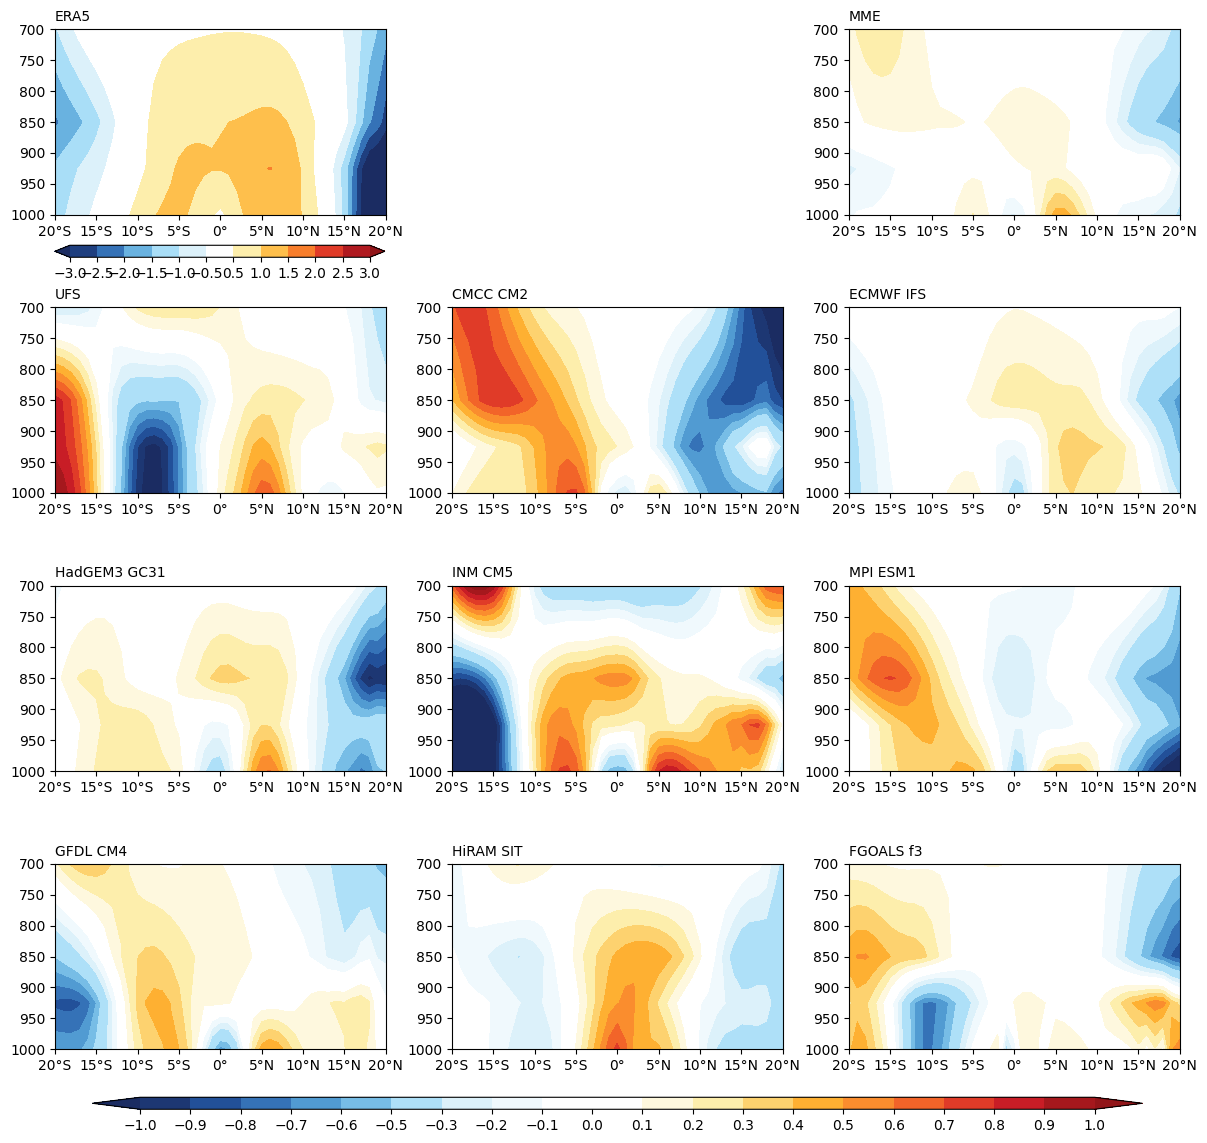

In [6]:
## PLOT Weekly Bias
mod = mod_anom.sel(longitude=slice('210','271'))
print(mod)
fig = plt.figure(figsize=(15,12))
plt.subplots_adjust(bottom=0.1,top=0.95,left=0.05,right=0.8)
model = ['ERA5','UFS','CMCC CM2','ECMWF IFS','HadGEM3 GC31','INM CM5','MPI ESM1','GFDL CM4','HiRAM SIT','FGOALS f3']
projection = ccrs.PlateCarree(central_longitude=180.0)
lon_tick = np.arange(-180,181,60) ## Add 1 in end-point
lat_tick = np.arange(-60,81,5)
lon_formatter = LongitudeFormatter(zero_direction_label = True)
lat_formatter = LatitudeFormatter()
#plt.set_cmap(cmaps.WhiteBlueGreenYellowRed)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)# color map
#clevs = [-3,-2.5,-2,-1.5,-1.0,-0.5,0.5,1.0,1.5,2.0,2.5,3]

clevs = np.arange(270,305,3)
clevs = np.arange(-3,3.1,0.5)
clevs = clevs[clevs!=clevs[6]]
plt.subplot(431)
lev = mod['level']
latitude = mod['latitude']
a=plt.contourf(latitude,lev,mod[0,:,:].mean('longitude'),levels=clevs,extend='both')
plt.gca().set_xticks(lat_tick)
plt.gca().xaxis.set_major_formatter(lat_formatter)
plt.gca().set_title('ERA5',loc='left',fontsize=10)
plt.gca().invert_yaxis()
plt.xlim(-20, 20)
plt.ylim(1000,700)
cax = plt.axes([0.05,0.76,0.22,0.01]) # Left, Bottom, width, height
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')

clevs = np.arange(-1,1.1,0.1)
clevs = clevs[clevs!=clevs[6]]

plt.subplot(4,3,3)
a=plt.contourf(latitude,lev,mod[1:,:,:].mean(('model','longitude')) - mod[0,:,:].mean('longitude'),levels=clevs,extend='both')
#a=plt.contourf(latitude,lev,mod[1:,:,:].mean(('model','longitude')),levels=clevs,extend='both')
plt.gca().set_xticks(lat_tick)
plt.gca().xaxis.set_major_formatter(lat_formatter)
plt.gca().set_title('ERA5',loc='left',fontsize=10)
plt.gca().invert_yaxis()
plt.gca().set_title('MME',loc='left',fontsize=10)
plt.xlim(-20, 20)
plt.ylim(1000,700)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)

for n in range(0,9):
    plt.subplot(4,3,4+n)
    a=plt.contourf(latitude,lev,mod[n+1,:,:].mean('longitude') - mod[0,:,:].mean('longitude'),levels=clevs,extend='both')
    #a=plt.contourf(latitude,lev,mod[n+1,:,:].mean('longitude'),levels=clevs,extend='both')
    plt.gca().set_xticks(lat_tick)
    plt.gca().xaxis.set_major_formatter(lat_formatter)
    plt.gca().set_title('MSWEP',loc='left',fontsize=10)
    plt.gca().invert_yaxis()
    plt.gca().set_title(model[n+1],loc='left',fontsize=10)
    plt.xlim(-20, 20)
    plt.ylim(1000,700)
    plt.set_cmap(cmaps.BlueWhiteOrangeRed)   # color map
    
cax = plt.axes([0.075,0.05,0.7,0.01]) # Left, Bottom, width, height
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')
plt.subplots_adjust(hspace=0.5)

In [7]:
qbias = (mod[:]-mod[0]).sel(latitude=slice(-10,-5),level=slice(1000,850))
print(qbias.mean(('latitude','longitude','level')))
'''
print(ufs.mean(('latitude','longitude')))

sstb = (mod[:]-mod[0]).sel(latitude=slice(-15,0),longitude=slice(210,275))
print(sstb.mean(('latitude','longitude')))
print(sstb.model)
'''

<xarray.DataArray 'tv' (model: 10)> Size: 80B
array([ 0.        , -0.78382622,  0.51598099,  0.07272397,  0.15677118,
        0.45655348,  0.29935329,  0.34576313, -0.11107663, -0.28050465])
Coordinates:
  * model    (model) <U15 600B 'ERA5' 'UFS-P8-V16' ... 'FGOALS-f3-H'


"\nprint(ufs.mean(('latitude','longitude')))\n\nsstb = (mod[:]-mod[0]).sel(latitude=slice(-15,0),longitude=slice(210,275))\nprint(sstb.mean(('latitude','longitude')))\nprint(sstb.model)\n"

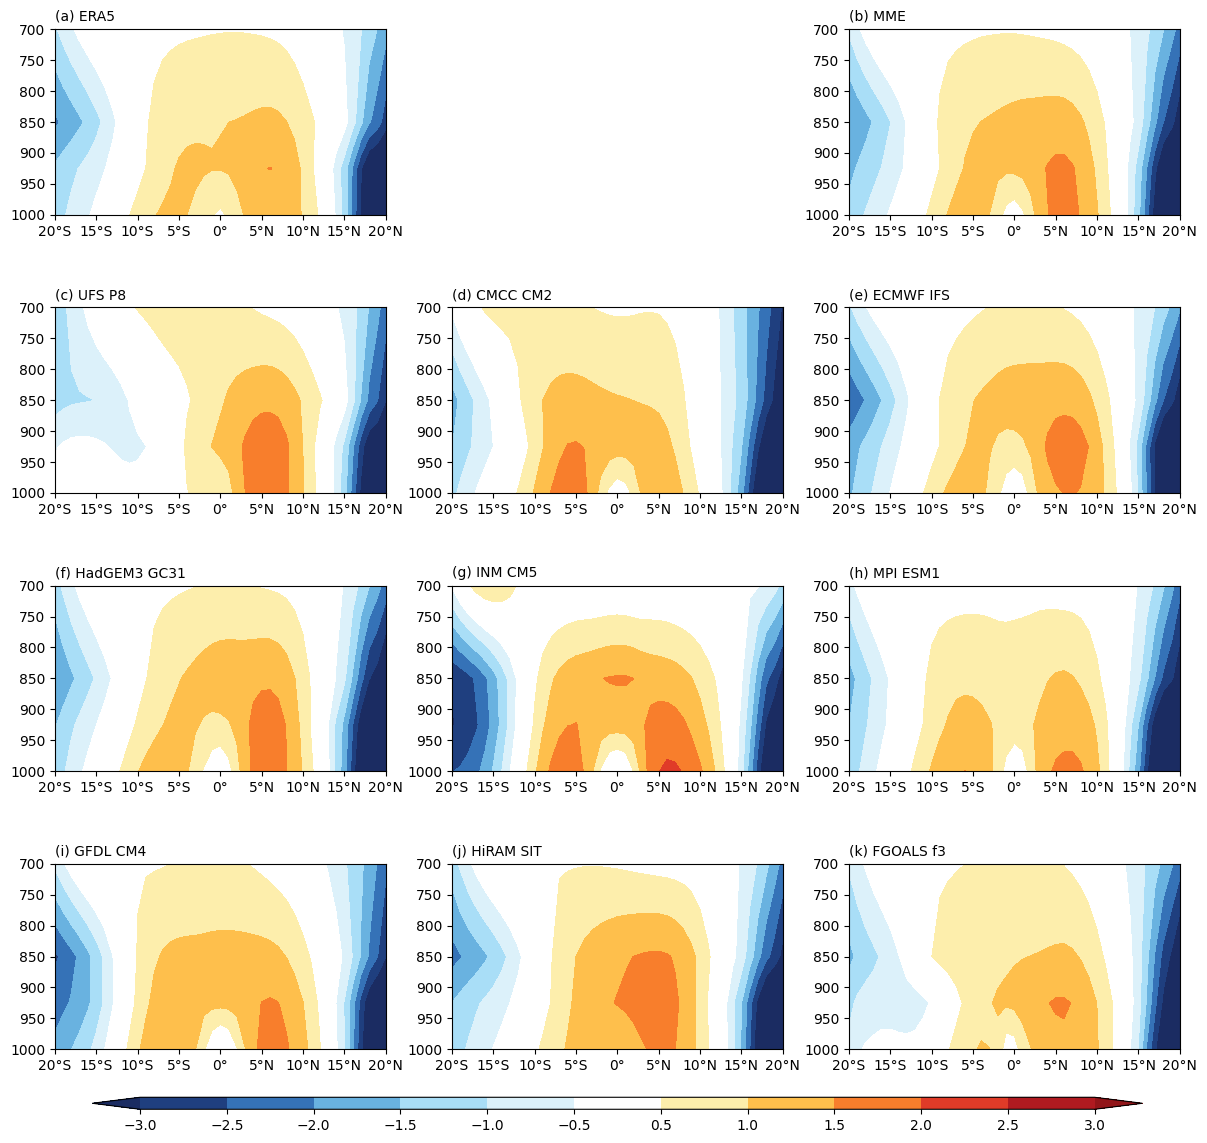

In [8]:
## PLOT Weekly Bias
mod = mod_anom.sel(longitude=slice('210','271'))
fig = plt.figure(figsize=(15,12))
plt.subplots_adjust(bottom=0.1,top=0.95,left=0.05,right=0.8)
model = ['ERA5','UFS P8','CMCC CM2','ECMWF IFS','HadGEM3 GC31','INM CM5','MPI ESM1','GFDL CM4','HiRAM SIT','FGOALS f3']
projection = ccrs.PlateCarree(central_longitude=180.0)
lon_tick = np.arange(-180,181,60) ## Add 1 in end-point
lat_tick = np.arange(-60,81,5)
lon_formatter = LongitudeFormatter(zero_direction_label = True)
lat_formatter = LatitudeFormatter()
#plt.set_cmap(cmaps.WhiteBlueGreenYellowRed)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)# color map
#clevs = [-3,-2.5,-2,-1.5,-1.0,-0.5,0.5,1.0,1.5,2.0,2.5,3]

clevs = np.arange(270,305,3)
clevs = np.arange(-3,3.1,0.5)
clevs = clevs[clevs!=clevs[6]]
plt.subplot(431)
lev = mod['level']
latitude = mod['latitude']
a=plt.contourf(latitude,lev,mod[0,:,:].mean('longitude'),levels=clevs,extend='both')
plt.gca().set_xticks(lat_tick)
plt.gca().xaxis.set_major_formatter(lat_formatter)
plt.gca().set_title('(a) ERA5',loc='left',fontsize=10)
plt.gca().invert_yaxis()
plt.xlim(-20, 20)
plt.ylim(1000,700)
#cax = plt.axes([0.05,0.76,0.22,0.01]) # Left, Bottom, width, height
#cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')

clevs = np.arange(-3,3.1,0.5)
clevs = clevs[clevs!=clevs[6]]

plt.subplot(4,3,3)
#a=plt.contourf(latitude,lev,mod[1:,:,:].mean(('model','longitude')) - mod[0,:,:].mean('longitude'),levels=clevs,extend='both')
a=plt.contourf(latitude,lev,mod[1:,:,:].mean(('model','longitude')),levels=clevs,extend='both')
plt.gca().set_xticks(lat_tick)
plt.gca().xaxis.set_major_formatter(lat_formatter)
plt.gca().set_title('MSWEP',loc='left',fontsize=10)
plt.gca().invert_yaxis()
plt.gca().set_title('(b) MME',loc='left',fontsize=10)
plt.xlim(-20, 20)
plt.ylim(1000,700)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)

for n in range(0,9):
    plt.subplot(4,3,4+n)
    #a=plt.contourf(latitude,lev,mod[n,:,:].mean('longitude') - mod[0,:,:].mean('longitude'),levels=clevs,extend='both')
    a=plt.contourf(latitude,lev,mod[n+1,:,:].mean('longitude'),levels=clevs,extend='both')
    plt.gca().set_xticks(lat_tick)
    plt.gca().xaxis.set_major_formatter(lat_formatter)
    plt.gca().set_title('MSWEP',loc='left',fontsize=10)
    plt.gca().invert_yaxis()
    label = f"({chr(99+n)}) {model[n+1]}"   # 99= 'c'부터 시작
    plt.gca().set_title(label, loc='left', fontsize=10)
    plt.xlim(-20, 20)
    plt.ylim(1000,700)
    plt.set_cmap(cmaps.BlueWhiteOrangeRed)   # color map
    
cax = plt.axes([0.075,0.05,0.7,0.01]) # Left, Bottom, width, height
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')
plt.subplots_adjust(hspace=0.5)

In [9]:
pc = xr.open_dataset('DITCZ_index.nc').pcs[:,0]

In [10]:
import numpy as np
import xarray as xr
import dask.array as da
from scipy.stats import linregress

def reg(index: xr.DataArray, data: xr.DataArray) -> tuple[xr.DataArray, xr.DataArray]:
    """
    Dask를 활용하여 3D 데이터 (data)와 1D 인덱스 (index) 간 선형 회귀 분석을 병렬 처리하는 함수.

    매개변수:
    - index: xarray DataArray of shape (model,), 회귀분석의 독립변수
    - data: xarray DataArray of shape (model, latitude, longitude), 분석할 데이터

    반환값:
    - (latitude, longitude) 차원의 xarray DataArray, 회귀계수(기울기)와 p-value
    """

    # 인덱스와 데이터 값을 Dask 배열로 변환
    X = da.from_array(index.values, chunks=(index.sizes['time'],))
    Y = da.from_array(data.values, chunks=(data.sizes['model'], data.sizes['level'],data.sizes['latitude']))

    # 회귀 분석 수행 (Dask map_blocks 사용)
    def lin_regression(y, X):
        """ 단일 (lat, lon) 위치에서 선형 회귀 수행 및 p-value 계산 """
        if np.all(np.isnan(y)):  # 모든 값이 NaN이면 NaN 반환
            return np.nan, np.nan
        valid_mask = np.isfinite(y)  # NaN이 없는 값만 선택
        if np.sum(valid_mask) < 2:  # 최소 2개 이상의 유효한 데이터 필요
            return np.nan, np.nan
        
        # 회귀분석 수행
        slope, intercept, r_value, p_value, std_err = linregress(X[valid_mask], y[valid_mask])
        
        return slope, p_value  # 기울기와 p-value 반환

    # 병렬 연산 수행
    regression_results = da.apply_along_axis(lin_regression, 0, Y, X)

    # 결과 분리 (slope, p-value)
    slope_result = regression_results[0].compute()
    p_value_result = regression_results[1].compute()

    # 결과를 xarray DataArray로 변환
    regression = xr.DataArray(
        slope_result,
        dims=['level','latitude'],
        coords={'latitude': data.coords['latitude'],
                'level': data.coords['level']},
        name="Regression"
    )

    p_value = xr.DataArray(
        p_value_result,
        dims=['level','latitude'],
        coords={'latitude': data.coords['latitude'],
                'level': data.coords['level']},
        name="P-value"
    )

    return regression, p_value


In [11]:
pr_regres, pr_p = reg(pc,pr)

In [12]:
#pr_regres = xr.where(pr_p <= 0.05, pr_regres, np.nan)
#sst_regres = xr.where(sst_p <= 0.05, sst_regres, np.nan)
pr_p = xr.where(pr_p <= 0.05, pr_p, np.nan)

In [13]:
ds = xr.open_dataset('../ufs_climate/MAM/w_regression.nc')
w_sig = ds.w_sig
w_reg = ds.w_reg
print(w_reg)
#U_interp = w_sig.copy()
U_interp = np.zeros((11,181))

<xarray.DataArray 'w_reg' (lev: 11, lat: 181)> Size: 16kB
[1991 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lev      (lev) float64 88B 500.0 550.0 600.0 650.0 ... 900.0 950.0 1e+03


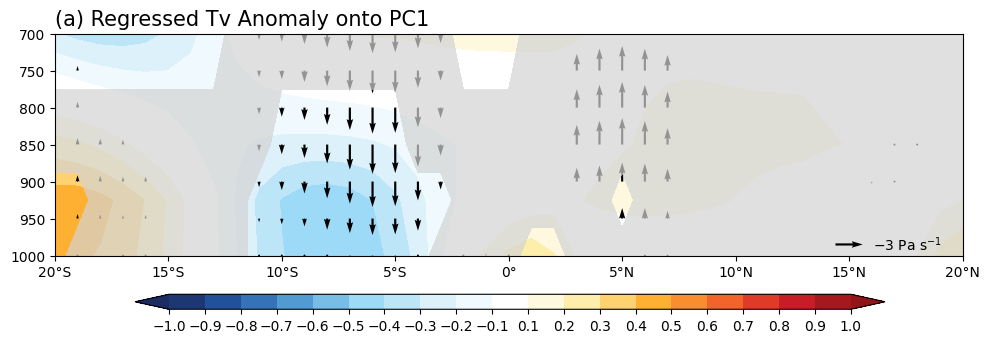

In [17]:
## PLOT Weekly Bias
fig = plt.figure(figsize=(10,3))
plt.subplots_adjust(bottom=0.2,top=0.95,left=0.05,right=0.8)
lat_tick = np.arange(-60,81,5)
lon_formatter = LongitudeFormatter(zero_direction_label = True)
lat_formatter = LatitudeFormatter()
#plt.set_cmap(cmaps.WhiteBlueGreenYellowRed)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)# color map
#clevs = [-3,-2.5,-2,-1.5,-1.0,-0.5,0.5,1.0,1.5,2.0,2.5,3]

clevs = np.arange(270,305,3)
clevs = np.arange(-1,1.1,0.1)
clevs = clevs[clevs!=clevs[10]]
plt.subplot(111)
lev = mod['level']
latitude = mod['latitude']
#plt.quiver(w_sig['lat'], w_sig['lev'], U_interp, w_reg, scale=100, zorder=2, color='darkgray')
Q = plt.quiver(w_sig['lat'], w_sig['lev'], U_interp, w_sig*-1, scale=100, zorder=2)
b=plt.contourf(latitude,lev, np.isnan(pr_p), colors='lightgray', alpha=0.7,levels=[0.5, 1.5], zorder=2)
a=plt.contourf(latitude,lev,pr_regres,levels=clevs,extend='both')
plt.gca().set_xticks(lat_tick)
plt.gca().xaxis.set_major_formatter(lat_formatter)
plt.gca().set_title('(a) Regressed Tv Anomaly onto PC1',loc='left',fontsize=15)
plt.gca().invert_yaxis()
plt.xlim(-20, 20)
plt.ylim(1000,700)

plt.quiverkey(Q, X=0.89, Y=0.05, U=3, 
              label=r'$-3\ \mathrm{Pa}\ \mathrm{s}^{-1}$', 
              labelpos='E', coordinates='axes', fontproperties={'size':10})

cax = plt.axes([0.14,-0.05,0.75,0.05])
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')
#ticks = cb.get_ticks()[::2]  # 기존 눈금에서 2칸마다 선택
#cb.set_ticks(ticks)
#cb.set_ticks((-1,-0.8,-0.6,-0.4,-0.2,0.2,0.4,0.6,0.8,1))
plt.tight_layout()
plt.savefig('fig3a.png', dpi=1000)

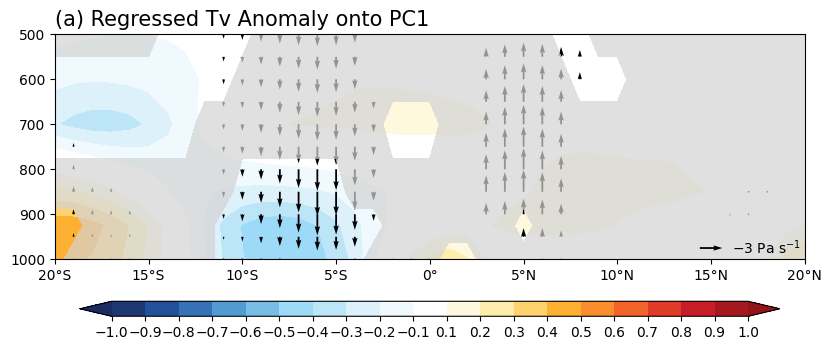

In [15]:
## PLOT Weekly Bias
fig = plt.figure(figsize=(10,3))
plt.subplots_adjust(bottom=0.2,top=0.95,left=0.05,right=0.8)
lat_tick = np.arange(-60,81,5)
lon_formatter = LongitudeFormatter(zero_direction_label = True)
lat_formatter = LatitudeFormatter()
#plt.set_cmap(cmaps.WhiteBlueGreenYellowRed)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)# color map
#clevs = [-3,-2.5,-2,-1.5,-1.0,-0.5,0.5,1.0,1.5,2.0,2.5,3]

clevs = np.arange(270,305,3)
clevs = np.arange(-1,1.1,0.1)
clevs = clevs[clevs!=clevs[10]]
plt.subplot(111)
lev = mod['level']
latitude = mod['latitude']
#plt.quiver(w_sig['lat'], w_sig['lev'], U_interp, w_reg, scale=100, zorder=2, color='darkgray')
Q = plt.quiver(w_sig['lat'], w_sig['lev'], U_interp, w_sig*-1, scale=100, zorder=2)
b=plt.contourf(latitude,lev, np.isnan(pr_p), colors='lightgray', alpha=0.7,levels=[0.5, 1.5], zorder=2)
a=plt.contourf(latitude,lev,pr_regres,levels=clevs,extend='both')
plt.gca().set_xticks(lat_tick)
plt.gca().xaxis.set_major_formatter(lat_formatter)
plt.gca().set_title('(a) Regressed Tv Anomaly onto PC1',loc='left',fontsize=15)
plt.gca().invert_yaxis()
plt.xlim(-20, 20)
plt.ylim(1000,500)

plt.quiverkey(Q, X=0.89, Y=0.05, U=3, 
              label=r'$-3\ \mathrm{Pa}\ \mathrm{s}^{-1}$', 
              labelpos='E', coordinates='axes', fontproperties={'size':10})

cax = plt.axes([0.075,0.01,0.7,0.05]) # Left, Bottom, width, height
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')
#ticks = cb.get_ticks()[::2]  # 기존 눈금에서 2칸마다 선택
#cb.set_ticks(ticks)
#cb.set_ticks((-1,-0.8,-0.6,-0.4,-0.2,0.2,0.4,0.6,0.8,1))